# 01 - Inspect Sub001

Goal: load one real EMG/kinematics recording, inspect shapes, and build the first feature matrix for the week 1 pipeline.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().parent
SRC_ROOT = PROJECT_ROOT / "src"
DATA_ROOT = PROJECT_ROOT / "data"

sys.path.insert(0, str(SRC_ROOT))

In [2]:
from emg_hls4ml_mvp.data_loading import (
    EMG_SAMPLE_RATE_HZ,
    KINEMATICS_SAMPLE_RATE_HZ,
    load_angles_csv,
    load_emg_csv,
    recording_paths,
)
from emg_hls4ml_mvp.dataset import build_feature_dataset

In [3]:
subject = "Sub001"
recording_id = "Sub001_1_05_450_0"
target_column = "index_z"

emg_path, angles_path = recording_paths(DATA_ROOT, subject, recording_id)
emg_path, angles_path

(PosixPath('/Users/joaogabriel/Library/Mobile Documents/com~apple~CloudDocs/Documents/workingOn/emg_hls4ml_mvp/data/raw/Sub001/HD_sEMG/Sub001_1_05_450_0.csv'),
 PosixPath('/Users/joaogabriel/Library/Mobile Documents/com~apple~CloudDocs/Documents/workingOn/emg_hls4ml_mvp/data/raw/Sub001/HandKinematics/Angles/Sub001_1_05_450_0.csv'))

In [4]:
emg = load_emg_csv(emg_path)
angles = load_angles_csv(angles_path)

emg.shape, angles.shape, angles.columns.tolist()

((92160, 128),
 (4500, 17),
 ['frame',
  'sub_frame',
  'thumb_x',
  'thumb_y',
  'thumb_z',
  'index_x',
  'index_y',
  'index_z',
  'middle_x',
  'middle_y',
  'middle_z',
  'ring_x',
  'ring_y',
  'ring_z',
  'little_x',
  'little_y',
  'little_z'])

At this point, `emg` and `angles` are pandas DataFrames: named tables that are convenient for inspection. The processing functions convert them to numpy arrays when they need matrix operations.

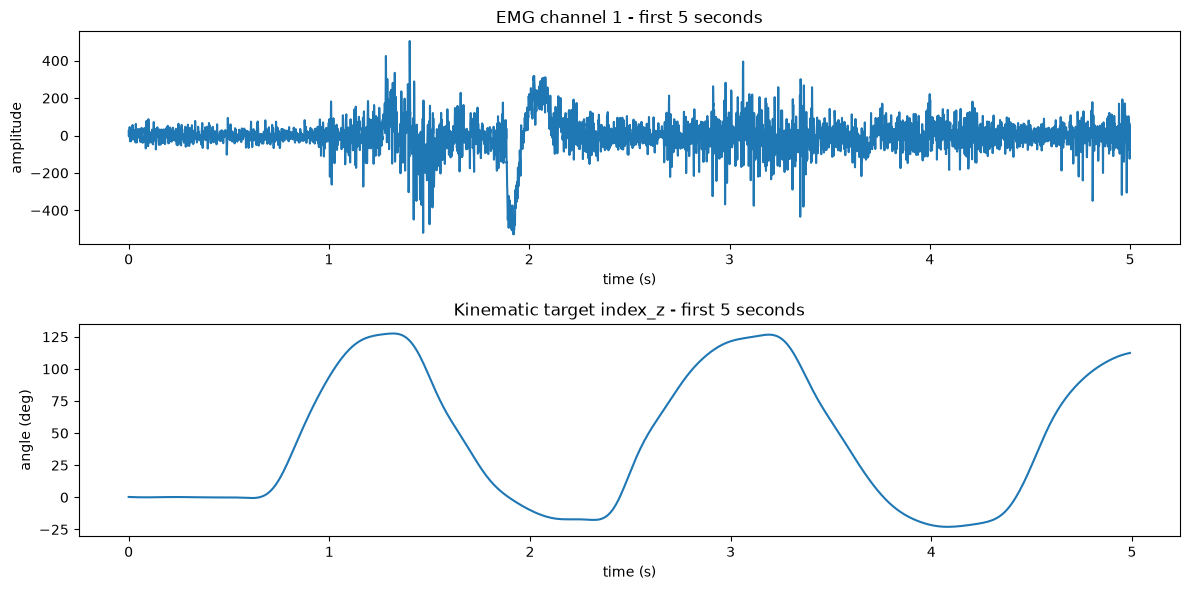

In [5]:
seconds_to_plot = 5
emg_samples = int(seconds_to_plot * EMG_SAMPLE_RATE_HZ)
kin_samples = int(seconds_to_plot * KINEMATICS_SAMPLE_RATE_HZ)

emg_time = np.arange(emg_samples) / EMG_SAMPLE_RATE_HZ
kin_time = np.arange(kin_samples) / KINEMATICS_SAMPLE_RATE_HZ

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)
axes[0].plot(emg_time, emg["ch_001"].iloc[:emg_samples])
axes[0].set_title("EMG channel 1 - first 5 seconds")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("amplitude")

axes[1].plot(kin_time, angles[target_column].iloc[:kin_samples])
axes[1].set_title(f"Kinematic target {target_column} - first 5 seconds")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("angle (deg)")

plt.tight_layout()

In [6]:
X, y, label_indices = build_feature_dataset(
    DATA_ROOT,
    subject,
    recording_id,
    target_column=target_column,
)

X.shape, y.shape, label_indices.shape

((3500, 384), (3500,), (3500,))

In [7]:
print(f"Feature matrix X: {X.shape} | dtype={X.dtype}")
print(f"Target vector y:  {y.shape} | dtype={y.dtype}")
print(f"First/last label index: {label_indices[0]} / {label_indices[-1]}")
print(f"Target range: {y.min():.3f} to {y.max():.3f} deg")

Feature matrix X: (3500, 384) | dtype=float32
Target vector y:  (3500,) | dtype=float32
First/last label index: 500 / 3999
Target range: -18.942 to 125.819 deg
